# Decision Tree on Iris Dataset

## Part1

Q1. What features does the Iris dataset include, and what is the Target (Goal) in this data?

Based on the execution and standard knowledge of the dataset:

**Features:**
he Iris dataset includes four numerical features:

- sepal length (cm) 
- sepal width (cm) 
- petal length (cm) 
- petal width (cm)  


**Target:**
The goal of the classification is to predict the species of the Iris flower. The three classes are:

- setosa 
- versicolor 
- virginica

In [1]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# 1. Identify the features (attributes)
features = iris.feature_names

# 2. Identify the target (goal)
target = iris.target_names
target_description = "The species of the Iris flower"

# Print the results
print(" Iris Dataset Analysis ")
print(f"Features: {features}")
print(f"Target: {target_description}")
print(f"Target Classes: {target}")

 Iris Dataset Analysis 
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target: The species of the Iris flower
Target Classes: ['setosa' 'versicolor' 'virginica']


---

Q2. How many rows and columns does it have?

#### Load the file and check structure 


In [2]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv('dataset/iris.csv')
print("Data Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")



Data Shape:
Rows: 150, Columns: 5


In [3]:
print("First 5 Rows:\n")
display(df.head())

First 5 Rows:



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Data Info:\n")
print(df.info())  

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


---

Q3. Are there any missing data or outliers in the dataset? How do you check?

The standard way to check for missing values (NaN or null values) is to use the .isnull() method followed by .sum() on the DataFrame.

In [5]:
print("Checking for Missing Values")
missing_values = df.isnull().sum()
print(missing_values)

total_missing = missing_values.sum()
if total_missing == 0:
    print("\nConclusion: The dataset has NO missing values.")
else:
    print(f"\nConclusion: Total missing values found: {total_missing}")

Checking for Missing Values
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Conclusion: The dataset has NO missing values.


---

Q4.How many classes does the target column (species) have, and what is their distribution?

In [6]:
# number of unique classes
num_classes = df['species'].nunique()

# distribution of samples per class
class_distribution = df['species'].value_counts()

# (0, 1, 2) back to their species names:
target_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
distribution_named = class_distribution.rename(index=target_names)

print("--- Target Class Analysis ---")
print(f"Number of Classes : {num_classes}")
print("\nDistribution of Classes :")
print(distribution_named)

--- Target Class Analysis ---
Number of Classes : 3

Distribution of Classes :
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\New\AppData\Local\Temp\ipykernel_13672\604529318.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution_named.index, y=distribution_named.values, palette='viridis')


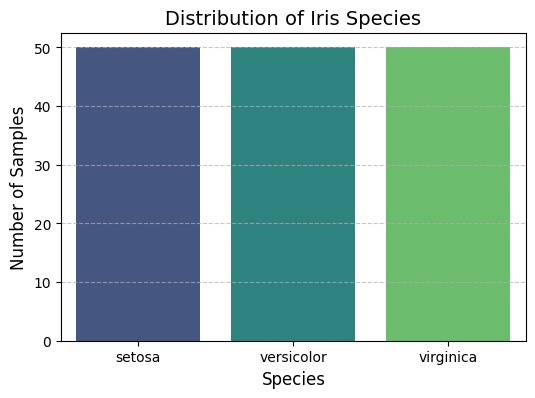

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

class_distribution = df['species'].value_counts()

target_names = {0: 'Iris Setosa', 1: 'Iris Versicolor', 2: 'Iris Virginica'}
distribution_named = class_distribution.rename(index=target_names)

plt.figure(figsize=(6, 4))
sns.barplot(x=distribution_named.index, y=distribution_named.values, palette='viridis')

plt.title('Distribution of Iris Species', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
 

 

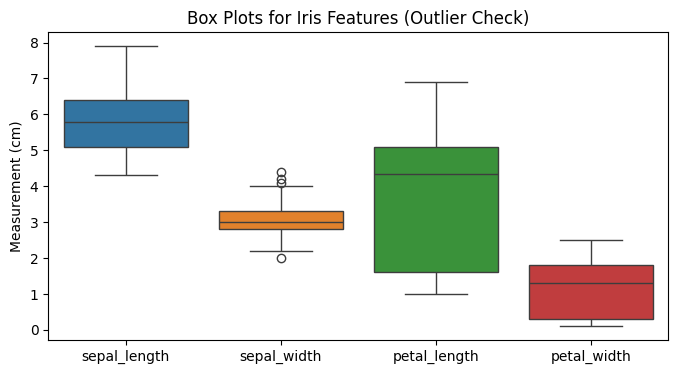

In [8]:
feature_cols = df.columns[:-1]

# visualization
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[feature_cols])
plt.title('Box Plots for Iris Features (Outlier Check)')
plt.ylabel('Measurement (cm)')
plt.show()

---

Q5. Divide the data into two sections: X (features) and y (target). How many features are in X?

#### We will separate the DataFrame (df) into two variables:

- X: The feature matrix (contains all columns except the target).

- y: The target vector (contains only the target column).

In [9]:
X = df.drop(columns=['species'])
y = df['species']
num_features_in_X = X.shape[1]

print(" Data Split Analysis:\n ")
print(f"X (Features) shape: {X.shape}")
print(f"y (Target) shape: {y.shape}")

print(f"\nNumber of Features in X : {num_features_in_X}")


 Data Split Analysis:
 
X (Features) shape: (150, 4)
y (Target) shape: (150,)

Number of Features in X : 4


---

Q6. Split the data into training and testing sets using train_test_split. Why do we use stratify?

We use the stratify parameter to ensure that the proportions of the different classes in the target variable ($\mathbf{y}$) are maintained in both the training and testing subsets1.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  
)

print("Train/Test Split Details")
print(f"Original samples: {len(y)}")
print(f"Training samples: {len(y_train)}")
print(f"Testing samples: {len(y_test)}")
print("\nTraining Set Class Distribution:")
print(y_train.value_counts())

Train/Test Split Details
Original samples: 150
Training samples: 105
Testing samples: 45

Training Set Class Distribution:
species
versicolor    35
setosa        35
virginica     35
Name: count, dtype: int64


---

Q7. Create a base Decision Tree model and train it on the training data. What is the initial model's accuracy?

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

#Training data Accuracy
train_accuracy = model.score(X_train, y_train)

print("Base Decision Tree Model Analysis")
print(f"Initial Training Accuracy : {train_accuracy:.4f}")

# Test Accuracy
test_accuracy = model.score(X_test, y_test)
print(f"Initial Test Accuracy: {test_accuracy:.4f}")

Base Decision Tree Model Analysis
Initial Training Accuracy : 1.0000
Initial Test Accuracy: 0.9333


---

Q8. What criterion do you use for splitting? What is the difference between Gini and Entropy?

In [12]:
print("Splitting Criterion Used")
default_criterion = model.criterion
print(f"Default Criterion: '{default_criterion}'")

Splitting Criterion Used
Default Criterion: 'gini'


1. Splitting Criterion Used:

In the base Decision Tree model, the default criterion used for splitting is Gini Impurity (Gini).

2. Difference Between Gini and Entropy:

**Gini Impurity (Gini)**

The Gini Impurity measures the probability of **misclassifying** a randomly chosen element in the node if it were randomly labeled according to the distribution of labels in that node.

* **Goal:** To **minimize** the impurity. The algorithm seeks the split that results in the smallest Gini Impurity in the resulting child nodes. A Gini score of 0 means the node is **pure** (all samples belong to the same class).
* **Formula:**
    $$\text{Gini} = 1 - \sum_{i=1}^{C} (p_i)^2$$
    Where $C$ is the number of classes, and $p_i$ is the fractional representation of class $i$ in the node.
* **Advantage:** It is computationally **faster** than Entropy because it does not involve logarithmic calculations. This is why it is the default choice in many libraries like scikit-learn.




**Entropy and Information Gain**

**Entropy** is a measure of the **randomness** or **disorder** (impurity) in the class distribution of a node. High entropy means the classes are mixed (high disorder), while low entropy means the node is pure (low disorder).

* **Goal:** Decision Trees aim to **maximize Information Gain** (the reduction in entropy). Information Gain is calculated as the difference between the parent node's entropy and the weighted average of the child nodes' entropies.
* **Formula (Entropy):**
    $$E = - \sum_{i=1}^{C} p_i \log_2(p_i)$$
    Where $C$ is the number of classes, and $p_i$ is the fractional representation of class $i$ in the node.
* **Advantage:** It is rooted in Information Theory and tends to produce slightly more **balanced** tree structures.

---
 

Q9. Test the Decision Tree with different max_depth parameters (e.g., 2, 3, 5, None). How does the accuracy change in each case?

In [13]:
# List of numeric max_depth values  
depths_to_test = [2, 3, 5]
results= []

for depth in depths_to_test:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    results.append({
        'Max Depth': depth,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)


   Max Depth  Train Accuracy  Test Accuracy
0          2        0.971429       0.888889
1          3        0.980952       0.977778
2          5        1.000000       0.933333


---

Q10. Using GridSearchCV, find the best combination of parameters (criterion, max_depth, min_samples_split).

In [14]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid (search space)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None], 
    'min_samples_split': [2, 5, 10]    
}

# Create the base model
dt_model = DecisionTreeClassifier(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=dt_model, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1  # Use all available cores
)

# Run the grid search on the training data
grid_search.fit(X_train, y_train)

# Extract the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(" GridSearchCV Results")
print(f"Best Cross-Validation Score : {best_score:.4f}")
print(f"Best Parameters Found : {best_params}")

 GridSearchCV Results
Best Cross-Validation Score : 0.9524
Best Parameters Found : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


---
---

## Part2

Q1. What are the best parameters found by GridSearchCV?

In [15]:
# Extract the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(" GridSearchCV Results")
print(f"Best Cross-Validation Score : {best_score:.4f}")
print(f"Best Parameters Found : {best_params}")

 GridSearchCV Results
Best Cross-Validation Score : 0.9524
Best Parameters Found : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


The optimal hyperparameters found by `GridSearchCV` are:

  * **`criterion`**: **gini**
  * **`max_depth`**: **3**
  * **`min_samples_split`**: **2**

This combination ensures the tree is simple enough to generalize well (due to the `max_depth=3`) while using the most common splitting criterion (`gini`) and allowing splits down to the smallest size (`min_samples_split=2`).

---

Q2. What is the accuracy of the optimized model on the test data?

In [16]:
#Best Parameters
best_params = {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

# Train the final optimized model
final_model = DecisionTreeClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)

test_accuracy = final_model.score(X_test, y_test)
print("(Optimized Model Evaluation)")
print(f"Best Parameters: {best_params}")
print(f"(Test Accuracy): {test_accuracy:.4f}")

(Optimized Model Evaluation)
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
(Test Accuracy): 0.9778


---

Q3. Print the classification report. Which species were most often misclassified?

In [17]:
from sklearn.metrics import classification_report

# Generate predictions
y_pred = final_model.predict(X_test)

# Print the classification report
report = classification_report(y_test, y_pred, target_names=target)

print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



The overall test **accuracy** is **0.98** ($\sim 97.78\%$), indicating only **one error** out of 45 test samples. We look at the **Recall** score for each class to identify where the model failed to find a sample (a False Negative).

1.  **setosa:** Perfect scores ($1.00$ Recall). No errors.
2.  **virginica:** Perfect Recall ($1.00$). All 15 actual Virginica samples were correctly identified.
3.  **versicolor:** Recall is **$0.93$**.

**Conclusion:**

The low Recall for **versicolor** (0.93) means that **1 out of the 15 actual Versicolor samples** was not classified as Versicolor (it was a **False Negative**).

Therefore, **Iris Versicolor** is the species that was **misclassified** in the test set. (As shown by the confusion matrix, this sample was mistakenly predicted as *virginica*).


---


4. Plot and analyze the confusion matrix. What does each row and column signify?

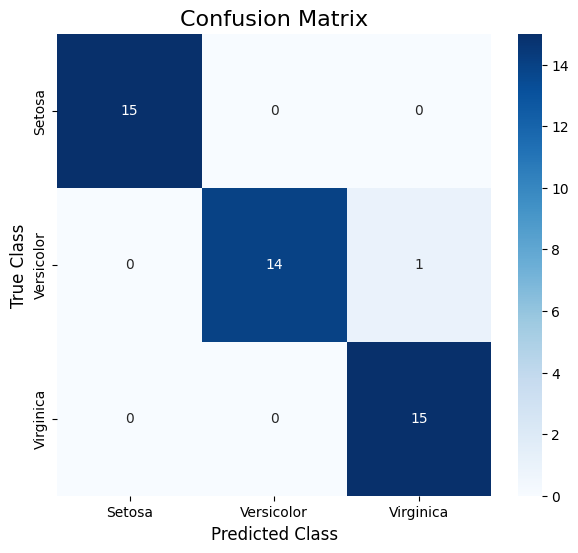

In [18]:
from sklearn.metrics import confusion_matrix

# Generate predictions
y_pred = final_model.predict(X_test)

# Calculate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
target_names_fa = ['Setosa', 'Versicolor', 'Virginica'] 

# Plot the confusion matrix 
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=target_names_fa,
    yticklabels=target_names_fa
)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.show()



The Confusion Matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known.

#### 1\. Rows: Actual Class (True Labels)

  * **Significance:** Each **row** represents the samples belonging to a specific **true class** in the dataset.
  * **Analysis:** The second row ("Actual: versicolor") shows that there were **15 actual Versicolor** samples in the test set.

#### 2\. Columns: Predicted Class

  * **Significance:** Each **column** represents the samples that were **predicted** to belong to a specific class by the model.
  * **Analysis:** The third column ("Predicted: virginica") shows that the model classified 16 total samples as Virginica (15 correct + 1 incorrect).

#### 3\. Interpretation of Values

  * **Main Diagonal (Correct Predictions):** The numbers along the main diagonal (**15, 14, 15**) are the **True Positives**—cases where the model correctly predicted the class.
  * **Off-Diagonal Values (Errors):** These show the misclassifications. The value **1** at Row 2 (Actual: versicolor) and Column 3 (Predicted: virginica) is the single error.

**Conclusion:**

  * The model made **one mistake** (as reflected by the test accuracy of $0.9778$).
  * This error was a **Versicolor sample** that was incorrectly predicted as **Virginica**.
  ---

5. Plot the final Decision Tree using plot_tree. Which feature is at the root of the tree?

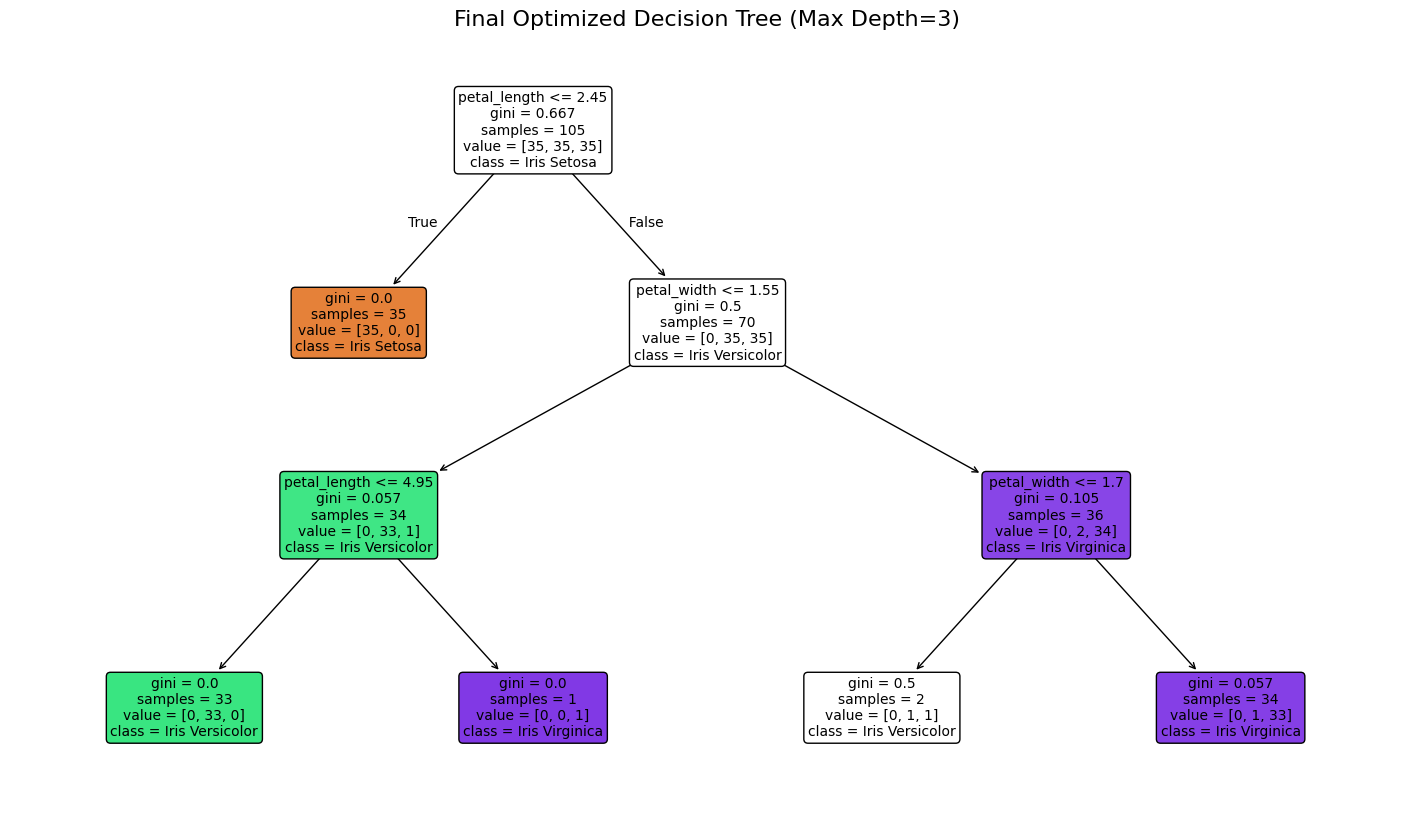

In [19]:
from sklearn.tree import plot_tree 

# Plot the Final Decision Tree 
plt.figure(figsize=(18, 10))
plot_tree(
    final_model,
    feature_names=X.columns.tolist(),
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Final Optimized Decision Tree (Max Depth=3)', fontsize=16)
plt.show()



###  Feature at the Root of the Tree

After generating and inspecting the plot :

The very first node at the top of the Decision Tree is the **Root Node**. This node contains the first and most critical splitting condition determined by the algorithm.

The splitting condition at the Root Node is:
$$\text{petal length (cm)} \le 2.45$$

The feature at the root of the tree is **petal length (cm)**.

---

6. Logically, is this feature suitable for separating the species? Why?

**Yes, the feature petal length (cm) is highly suitable for separating the Iris species.**

#### Reasoning:

1.  **High Information Gain:** The Decision Tree algorithm selects this feature because it provides the greatest reduction in impurity (highest information gain or lowest Gini impurity) compared to any other feature.


2.  **Clear Segregation of Setosa:** Petal length is the best discriminator for isolating the Iris Setosa species. All Setosa flowers have very small petals ($\le 2.45 \text{ cm}$), allowing the first split to almost perfectly separate them from Versicolor and Virginica.


3.  **Efficiency:** By handling the easiest classification first, the tree becomes highly efficient, needing only two more splits (as constrained by $\text{max\_depth}=3$) to achieve near-perfect classification for all three species.

---

7. If your tree shows Overfitting, what adjustments can you make to simplify the tree?

Overfitting occurs when a Decision Tree is too complex (too deep) and learns the noise in the training data rather than the underlying pattern. To simplify the tree and improve its generalization ability, you should use **pre-pruning** techniques (regularization via hyperparameter tuning).

Here are the key adjustments we can make to simplify the tree:

1.  **Limit Maximum Depth (`max_depth`)**
    * **Action:** Set a predefined maximum depth (e.g., 3, 5, or 10) for the tree.
    * **Effect:** This stops the tree from growing indefinitely, preventing it from making overly specific splits on small subsets of noisy data. This is the most common and effective way to fight overfitting.

2.  **Increase Minimum Samples per Split (`min_samples_split`)**
    * **Action:** Increase the minimum number of samples a node must contain before the algorithm considers splitting it.
    * **Effect:** Prevents the model from creating splits that are only relevant to a few samples, forcing the splits to be based on larger, more representative groups of data.

3.  **Increase Minimum Samples per Leaf (`min_samples_leaf`)**
    * **Action:** Increase the minimum number of samples required to exist in any final leaf node.
    * **Effect:** Ensures that every final decision (leaf) is based on a sufficiently large and reliable group of samples, preventing the model from achieving 100% training accuracy through overly small, pure leaves.

4.  **Use Cost-Complexity Pruning (Post-Pruning)**
    * **Action:** Use the $\text{ccp\_alpha}$ parameter (Cost-Complexity Pruning).
    * **Effect:** The algorithm builds a full tree first and then prunes back the branches that offer the least improvement in accuracy, leading to the most effective tradeoff between complexity and accuracy. This method is often more systematic than setting a fixed `max_depth`.

    ---

8. What is the concept of Pruning in Decision Trees, and what effect does it have on model performance?

##### 1. The Concept of Pruning

**Pruning** is a technique used to **reduce the size and complexity** of a Decision Tree by removing (or "cutting back") branches or nodes that provide little predictive power or are based on insufficient data.

An unconstrained Decision Tree often grows until its leaves are perfectly pure. This leads to the tree memorizing the training data, including its noise and outliers, resulting in **Overfitting**.

Pruning aims to simplify the model to improve its ability to **generalize** to new, unseen data.

There are two main types:

1.  **Pre-Pruning:** Stopping the tree-building process early by setting constraints before training. This is done using parameters like **max_depth** or **min_samples_split**.

2.  **Post-Pruning:** Building the full tree first, and then systematically removing branches that are found to be ineffective using cross-validation or validation data. (e.g., using **Cost-Complexity Pruning** or **ccp_alpha** in scikit-learn). 



##### 2. Effect on Model Performance

Pruning generally has several positive effects on model performance:

* **Reduces Overfitting:** This is the primary goal. By simplifying the tree, pruning makes the model less sensitive to noise in the training set, focusing it on the general patterns.


* **Improves Generalization (Test Accuracy):** A pruned tree is more robust and typically achieves better, more reliable accuracy on **unseen test data**.


* **Increases Interpretability:** A smaller, simpler tree is much easier for humans to understand, explain, and visualize.


* **Faster Training and Prediction:** A smaller model requires less memory and can be trained and used for prediction more quickly.

---

9. Explain the difference between a single Decision Tree and a Random Forest. Why is RF more stable?

#### 1. Comparison of Single Decision Tree and Random Forest

| Feature | Single Decision Tree | Random Forest (RF) |
| :--- | :--- | :--- |
| **Structure** | A **single**, monolithic model. | An **ensemble** (collection) of many independent Decision Trees. |
| **Training Data** | Uses the **entire training dataset** for every split. | Each tree is trained on a **random subset** of the data, selected with replacement (**Bootstrap Aggregation or Bagging**). |
| **Feature Selection** | Considers **all available features** for finding the best split at every node. | Considers only a **random subset of features** for finding the best split at every node. |
| **Final Prediction** | Based on the output of the single tree. | Based on the **majority vote** (for classification) or the average (for regression) of all trees in the forest. |




#### 2. Why Random Forest is More Stable

A **Single Decision Tree** suffers from **high variance**. This means that if you make small changes to the training data, the resulting tree structure can change drastically, making it sensitive to noise and prone to **overfitting**.

**Random Forest achieves superior stability and generalization through two key mechanisms of randomness:** 

1.  **Reduced Variance via Aggregation (Bagging):**
    * RF trains many diverse trees on different subsets of the data. Because these trees are trained somewhat independently, their individual errors are less correlated.
    * When RF combines their predictions (via voting or averaging), the random, uncorrelated errors of individual trees **cancel each other out**. This process significantly **reduces the model's overall variance** and makes the final prediction much more reliable and robust.

2.  **Increased Diversity via Feature Randomness:**
    * By restricting each tree to only use a random subset of features for splitting, RF prevents a single, very powerful feature from dominating the entire forest. This forces the individual trees to be even more diverse and uncorrelated, which is the cornerstone of the ensemble's stability and power.

In summary, Random Forest is stable because it combines predictions from a diverse set of models, acting as a powerful form of **error correction** and providing a more robust measure of the true underlying relationship in the data.

---


10. Finally, compare the performance and advantages of the Decision Tree versus KNN on the same data. In what conditions is one better than the other?

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# KNN is distance-based, so scaling is crucial.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Initialize the KNN model, using K=5 (a common default value)
k_value = 5
knn_model = KNeighborsClassifier(n_neighbors=k_value)

# Train the model on the scaled training data
knn_model.fit(X_train_scaled, y_train)

# Calculate accuracy on the scaled test data
test_accuracy = knn_model.score(X_test_scaled, y_test)

print("K-Nearest Neighbors (KNN) Performance")
print(f"K used (n_neighbors): {k_value}")
print(f"Test Accuracy for KNN: {test_accuracy:.4f}")


# Search for the best K value (1 to 10)
param_grid = {'n_neighbors': range(1, 11)}
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1
)
grid_search_knn.fit(X_train_scaled, y_train)

best_k = grid_search_knn.best_params_['n_neighbors']
best_score = grid_search_knn.best_score_
test_acc_best_k = grid_search_knn.best_estimator_.score(X_test_scaled, y_test)

print("\nKNN Optimization Results")
print(f"Optimal K found: {best_k}")
print(f"Best Cross-Validation Score: {best_score:.4f}")
print(f"Test Accuracy with Optimal K ({best_k}): {test_acc_best_k:.4f}")

K-Nearest Neighbors (KNN) Performance
K used (n_neighbors): 5
Test Accuracy for KNN: 0.9111

KNN Optimization Results
Optimal K found: 7
Best Cross-Validation Score: 0.9619
Test Accuracy with Optimal K (7): 0.9333


#### 1. Comparison of Performance and Advantages

Both models perform excellently on the clean Iris dataset (achieving high accuracy). However, their underlying mechanisms and practical advantages differ significantly:

| Feature | Decision Tree (DT) | K-Nearest Neighbors (KNN) |
| :--- | :--- | :--- |
| **Model Type** | **Parametric** (Creates a set of rules/structure during training). | **Non-Parametric** (Instance-based; stores all data). |
| **Training Time** | **Slower** (Must compute optimal splits). | **Very Fast** (Model simply stores the training data). |
| **Prediction Time** | **Very Fast** (Only follows the branches/rules). | **Slower** (Must compute the **distance** to *every* training sample). |
| **Interpretability** | **High** (Rules and feature importance are visible). | **Low to Medium** (Logic is simple, but the reason for a specific distance is hard to explain). |
| **Feature Scaling** | **Not Sensitive** (DTs use relative ordering, not absolute values). | **Highly Sensitive** (Scaling/normalization is **required** to prevent features with large ranges from dominating the distance calculation). |
| **Outliers/Noise** | **Sensitive** (Overfitting to noise leads to complex leaves). | **Sensitive** (Outliers can skew the distances to the nearest neighbors). |





#### 2. Conditions for Preference (When One is Better)

##### A. Decision Tree is Preferred If:

1.  **Interpretability and Explainability is Required:** DTs are superior when you need to understand the **rules** the model uses (e.g., "If petal length $\le 2.45$, then Setosa").
2.  **Prediction Speed is Critical:** In real-time systems, a DT's prediction speed is generally much faster than KNN's distance calculation.
3.  **The Dataset is Large:** DTs scale better to large datasets during the prediction phase, whereas KNN's prediction time increases linearly with the number of training samples.
4.  **Feature Scaling is Undesirable:** If you cannot or do not want to scale your features, DTs are robust to the original feature ranges.

##### B. K-Nearest Neighbors (KNN) is Preferred If:

1.  **The Decision Boundary is Highly Complex/Non-linear:** KNN can create arbitrary and complex local decision boundaries, sometimes outperforming rule-based models like DTs on highly intricate data manifolds.
2.  **Training Speed is the Priority:** If you need a model that trains almost instantly and your dataset is small, KNN is a simple baseline.
3.  **Low-Dimensional Data:** KNN performs well on data with fewer features, where calculating distances is computationally less intensive.

**for the Iris Data:**

Both models are highly effective. However, the **optimized Decision Tree** offers the best practical solution for the Iris dataset due to its **high interpretability** (explaining exactly why a flower is classified as it is) and its inherent robustness to feature scaling, making it easier to deploy without preprocessing steps.